In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation as R
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep
import os
import h5py
from ur_ikfast.ur_ikfast import ur_kinematics

In [2]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [ ]:
zarr_path = '/home/jaco/dataset.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")
episode_idx = np.random.choice(num_episodes)
print(f"Replaying episode {episode_idx}...")
ep = replay_buffer.get_episode(episode_idx)
# print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])
for robot_idx in range(1):
    pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
    rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
    grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

In [ ]:
cam_pose = np.concatenate([pos_replay, rot_replay], axis=-1)
cam_pose = pose_to_mat(cam_pose)
cam_pose.shape

In [ ]:
def plot_transformation(T, scale=0.1, frame_name="Frame"):
    # T: 4x4 transformation matrix
    origin = T[:3, 3]
    R = T[:3, :3]
    
    # Axes endpoints
    x_axis = origin + R[:, 0] * scale
    y_axis = origin + R[:, 1] * scale
    z_axis = origin + R[:, 2] * scale

    fig = go.Figure()
    
    # Plot origin
    fig.add_trace(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers', marker=dict(size=5, color='black'),
        name=f'{frame_name} origin'
    ))
    
    # X-axis (red)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], x_axis[0]],
        y=[origin[1], x_axis[1]],
        z=[origin[2], x_axis[2]],
        mode='lines', line=dict(color='red', width=5),
        name=f'{frame_name} x-axis'
    ))
    
    # Y-axis (green)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], y_axis[0]],
        y=[origin[1], y_axis[1]],
        z=[origin[2], y_axis[2]],
        mode='lines', line=dict(color='green', width=5),
        name=f'{frame_name} y-axis'
    ))
    
    # Z-axis (blue)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], z_axis[0]],
        y=[origin[1], z_axis[1]],
        z=[origin[2], z_axis[2]],
        mode='lines', line=dict(color='blue', width=5),
        name=f'{frame_name} z-axis'
    ))
    
    fig.update_layout(scene=dict(aspectmode='data'),
                      title=f"Transformation: {frame_name}")
    fig.show()


def get_frame_traces(T, scale=0.1, frame_name="Frame", colors=None):
    """
    Given a 4x4 transformation matrix T, returns a list of Plotly traces (Scatter3d)
    representing the coordinate axes of that frame.
    """
    origin = T[:3, 3]
    R = T[:3, :3]
    # Compute endpoints for axes
    x_axis = origin + R[:, 0] * scale
    y_axis = origin + R[:, 1] * scale
    z_axis = origin + R[:, 2] * scale

    if colors is None:
        colors = {'x': 'red', 'y': 'green', 'z': 'blue'}

    traces = []
    # Origin
    traces.append(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers',
        marker=dict(size=5, color='black'),
        name=f'{frame_name} Origin'
    ))
    # X-axis
    traces.append(go.Scatter3d(
        x=[origin[0], x_axis[0]],
        y=[origin[1], x_axis[1]],
        z=[origin[2], x_axis[2]],
        mode='lines',
        line=dict(color=colors['x'], width=5),
        name=f'{frame_name} X-axis'
    ))
    # Y-axis
    traces.append(go.Scatter3d(
        x=[origin[0], y_axis[0]],
        y=[origin[1], y_axis[1]],
        z=[origin[2], y_axis[2]],
        mode='lines',
        line=dict(color=colors['y'], width=5),
        name=f'{frame_name} Y-axis'
    ))
    # Z-axis
    traces.append(go.Scatter3d(
        x=[origin[0], z_axis[0]],
        y=[origin[1], z_axis[1]],
        z=[origin[2], z_axis[2]],
        mode='lines',
        line=dict(color=colors['z'], width=5),
        name=f'{frame_name} Z-axis'
    ))
    return traces

def add_traces(fig, T, scale=0.05, marker_color='black', marker_size=2):
    """
    Add traces for a single frame defined by transformation matrix T to the given figure.
    The traces will have no legend entries.
    """
    origin = T[:3, 3]
    R = T[:3, :3]
    fig.add_trace(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers',
        marker=dict(size=marker_size, color=marker_color),
        showlegend=False
    ))

def add_frame_traces(fig, T, scale=0.05):
    """
    Add traces for a single frame defined by transformation matrix T to the given figure.
    The traces will have no legend entries.
    """
    origin = T[:3, 3]
    R = T[:3, :3]
    # Calculate endpoints for each axis
    x_end = origin + R[:, 0] * scale
    y_end = origin + R[:, 1] * scale
    z_end = origin + R[:, 2] * scale
    
    # Create traces without legend entries (showlegend=False)
    # X-axis in red
    fig.add_trace(go.Scatter3d(
        x=[origin[0], x_end[0]],
        y=[origin[1], x_end[1]],
        z=[origin[2], x_end[2]],
        mode='lines',
        line=dict(color='red', width=2),
        showlegend=False
    ))
    # Y-axis in green
    fig.add_trace(go.Scatter3d(
        x=[origin[0], y_end[0]],
        y=[origin[1], y_end[1]],
        z=[origin[2], y_end[2]],
        mode='lines',
        line=dict(color='green', width=2),
        showlegend=False
    ))
    # Z-axis in blue
    fig.add_trace(go.Scatter3d(
        x=[origin[0], z_end[0]],
        y=[origin[1], z_end[1]],
        z=[origin[2], z_end[2]],
        mode='lines',
        line=dict(color='blue', width=2),
        showlegend=False
    ))
    # Optionally, add a marker at the origin
    fig.add_trace(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers',
        marker=dict(size=2, color='black'),
        showlegend=False
    ))

In [ ]:
tcp_offset = 0.205
cam_to_center_height = 0.086
cam_to_mount_offset = 0.01465
cam_to_tip_offset = cam_to_mount_offset + tcp_offset
pose_cam_tcp = np.array([0, cam_to_center_height, cam_to_tip_offset, 0,0,0])
tx_cam_tcp = pose_to_mat(pose_cam_tcp)
tx_tcp_cam = np.linalg.inv(tx_cam_tcp)

In [ ]:
mean_x = -0.058042273
mean_y = -0.13376735
mean_z = 0.09266995
mean_rx = -2.1256728
mean_ry = 0.0827507
mean_rz = 0.052626412

tx_tag_tcp= cam_pose

In [ ]:
tx_slam_tag = np.array([
    [
      0.999010800224083,
      0.04419283883966596,
      -0.00493732584247188,
      -0.038451282666388954
    ],
    [
      0.019925677699674696,
      -0.5441419461595277,
      -0.8387565327949628,
      0.10049407623530243
    ],
    [
      -0.039753639276792485,
      0.8378284779205093,
      -0.5444842672810158,
      0.5594021977928332
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
])

tx_tag_slam = np.linalg.inv(tx_slam_tag)

In [ ]:
tx_tag_base = np.array([
        [
      -0.9992668101498986,
      0.03786236221936187,
      0.005681871172127269,
      -0.018283582081895254
    ],
    [
      -0.03760656116820821,
      -0.998497334760624,
      0.03985999288801041,
      -0.49712673959771314
    ],
    [
      0.007182526710609295,
      0.03961709231001545,
      0.9991891198901993,
      -0.042018964151028
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  
  ])

tx_base_tag = np.linalg.inv(tx_tag_base)

In [ ]:
# camera pose in slam : tx_slam_cam

# tx_tag_cam = tx_tag_slam @ tx_slam_cam

# tx_tag_tcp = tx_tag_cam @ tx_cam_tcp


# from base to tcp
tx_base_tcp = tx_base_tag @ tx_tag_tcp

In [ ]:
def plot_traj(cam_pose):
    fig = go.Figure()
    n_frames = cam_pose.shape[0]
    subsample = 1  # You can adjust this if needed

    for i in range(0, n_frames, subsample):
        T = cam_pose[i]
        # Choose color and marker size based on the frame index.
        if i == 0:
            color = 'green'  # start frame
            size = 6
        elif i == n_frames - 1:
            color = 'red'    # end frame
            size = 6
        else:
            color = 'black'
            size = 2
        add_traces(fig, T, scale=0.05, marker_color=color, marker_size=size)

    fig.update_layout(
        scene=dict(aspectmode='data'),
        title="All Camera Poses (Frames)"
    )
    fig.show()

In [ ]:
# camera pose tag to tcp

plot_traj(cam_pose=cam_pose)

In [ ]:
tx_base_tcp2 = tx_tag_base @ tx_tag_tcp
plot_traj(tx_base_tcp2)
# this is right - the z axis height should be decrease

In [ ]:
tx_slam_cam = tx_slam_tag @ tx_tag_tcp @ tx_tcp_cam

In [ ]:
plot_traj(tx_slam_cam)

In [ ]:
action_lists = pickle.load(open('/home/jaco/act_actions.pkl', 'rb'))
all_unnorm_actions = action_lists[-1]
all_real_umi_actions = action_lists[0]
all_target_actions = action_lists[1]
all_tcp_pose = action_lists[2]

max_ep_length = len(all_real_umi_actions)
print("max ep length: ", max_ep_length)
# norm_action = np.zeros(shape=(max_ep_length, 4))
unnorm_action = np.zeros(shape=(max_ep_length, 6))
real_umi_action = np.zeros(shape=(max_ep_length, 6))
# real_umi_action_rot = np.zeros(shape=(max_ep_length, 6))
target_action = np.zeros(shape=(max_ep_length, 6))
# real_umi_action_180 = np.zeros(shape=(max_ep_length, 6))
tcp_pose = np.zeros(shape=(max_ep_length, 6))

# for idx, action in enumerate(all_norm_actions):
#     norm_action[idx, :3] = action[:3]
#     norm_action[idx, -1] = action[-1]

for idx, action in enumerate(all_unnorm_actions):
    unnorm_action[idx, :6] = action[:6]

for idx, action in enumerate(all_real_umi_actions):
    real_umi_action[idx, :6] = action[:6]
    # real_umi_action[idx, -1] = action[-1]
    # real_umi_action_rot[idx, :6] = action[:6]

for idx, action in enumerate(all_target_actions):
    target_action[idx, :6] = action[0][:6]
    # target_action[idx, :6] = action[0][:6]
    # target_action[idx, -1] = action[0][-1]

# for idx, action in enumerate(all_real_umi_actions_180):
#     real_umi_action_180[idx, :6] = action[:6]

for idx, action in enumerate(all_tcp_pose):
    tcp_pose[idx, :6] = action[:6]

In [ ]:
# base to tcp
unnorm_actions = np.array(unnorm_action)
unnorm_actions_mat = pose_to_mat(unnorm_actions)
plot_traj(unnorm_actions_mat)

In [ ]:
# relative action
real_actions = np.array(real_umi_action)
real_actions_mat = pose_to_mat(real_actions)
plot_traj(real_actions_mat)

In [ ]:
# executed action
target_actions = np.array(target_action)
target_actions_mat = pose_to_mat(target_actions)
plot_traj(target_actions_mat)

In [ ]:
# actual tcp poses
tcp_actions = np.array(all_tcp_pose)
tcp_actions_mat = pose_to_mat(tcp_actions)
plot_traj(tcp_actions_mat)

Joint Check

In [3]:
def add_traces(fig, T, scale=0.05, marker_color='black', marker_size=2):
    origin = T[:3, 3]
    R = T[:3, :3]
    fig.add_trace(go.Scatter3d(
        x=[origin[0]], y=[origin[1]], z=[origin[2]],
        mode='markers',
        marker=dict(size=marker_size, color=marker_color),
        showlegend=False
    ))

def plot_traj(cam_pose):
    fig = go.Figure()
    n_frames = cam_pose.shape[0]
    subsample = 1  

    for i in range(0, n_frames, subsample):
        T = cam_pose[i]
        if i == 0:
            color = 'green'  # start frame
            size = 6
        elif i == n_frames - 1:
            color = 'red'    # end frame
            size = 6
        else:
            color = 'black'
            size = 2
        add_traces(fig, T, scale=0.05, marker_color=color, marker_size=size)

    fig.update_layout(
        scene=dict(aspectmode='data'),
        title="All Camera Poses (Frames)"
    )
    fig.show()

In [4]:
num_episodes = 240
hdf5_path = '/home/soochul/GoPro_20250313_hdf5/'
episode_id = np.random.choice(num_episodes)
dataset_path = os.path.join(hdf5_path, f'ep_{episode_id}.hdf5')
joint_dataset_path = os.path.join(hdf5_path, f'j_ep_{episode_id}.hdf5')

    
with h5py.File(dataset_path, 'r') as root:
    is_sim = root.attrs['sim']
    original_action_shape = root['/action'].shape # ep length, 7
    episode_len = original_action_shape[0]
    start_ts = 0
    pose_action = root['/action'][start_ts:]

with h5py.File(joint_dataset_path, 'r') as root:
    is_sim = root.attrs['sim']
    original_action_shape = root['/action'].shape # ep length, 7
    episode_len = original_action_shape[0]
    start_ts = 0
    joint_action = root['/action'][start_ts:]



pose_trajectory = np.zeros((episode_len, 4, 4))
ur3_arm = ur_kinematics.URKinematics('ur5') # ur3

tx_tag_base = np.array([
    [
      0.014500569635805594,
      -0.9997530090623589,
      -0.016842041176650398,
      -0.044059934138102635
    ],
    [
      0.9996692201244223,
      0.014853059193052465,
      -0.02099611793729384,
      -0.4799630648844079
    ],
    [
      0.02124108792096622,
      -0.016532014498134257,
      0.9996376887055468,
      -0.02314005620630681
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  
  ])

tx_base_tag = np.linalg.inv(tx_tag_base)

eef_trajectory = np.zeros((episode_len, 4, 4))
cam_pose = pose10d_to_mat(pose_action[:, :-1])
tx_base_tcp = tx_base_tag @ cam_pose



In [9]:
def plot_joint_trajectory(joint_trajectory, timesteps, num_ur3_joints):
    fig, axs = plt.subplots(num_ur3_joints, 1, figsize=(10, 2 * num_ur3_joints), sharex=True)
    
    for joint in range(num_ur3_joints):
        axs[joint].plot(timesteps, joint_trajectory[:, joint], linestyle='-')
        axs[joint].set_title(f'Joint {joint + 1}')
        axs[joint].set_ylabel('Angle (radians)')
        axs[joint].grid(True)
    
    axs[-1].set_xlabel('Timesteps')
    plt.tight_layout()
    plt.show()

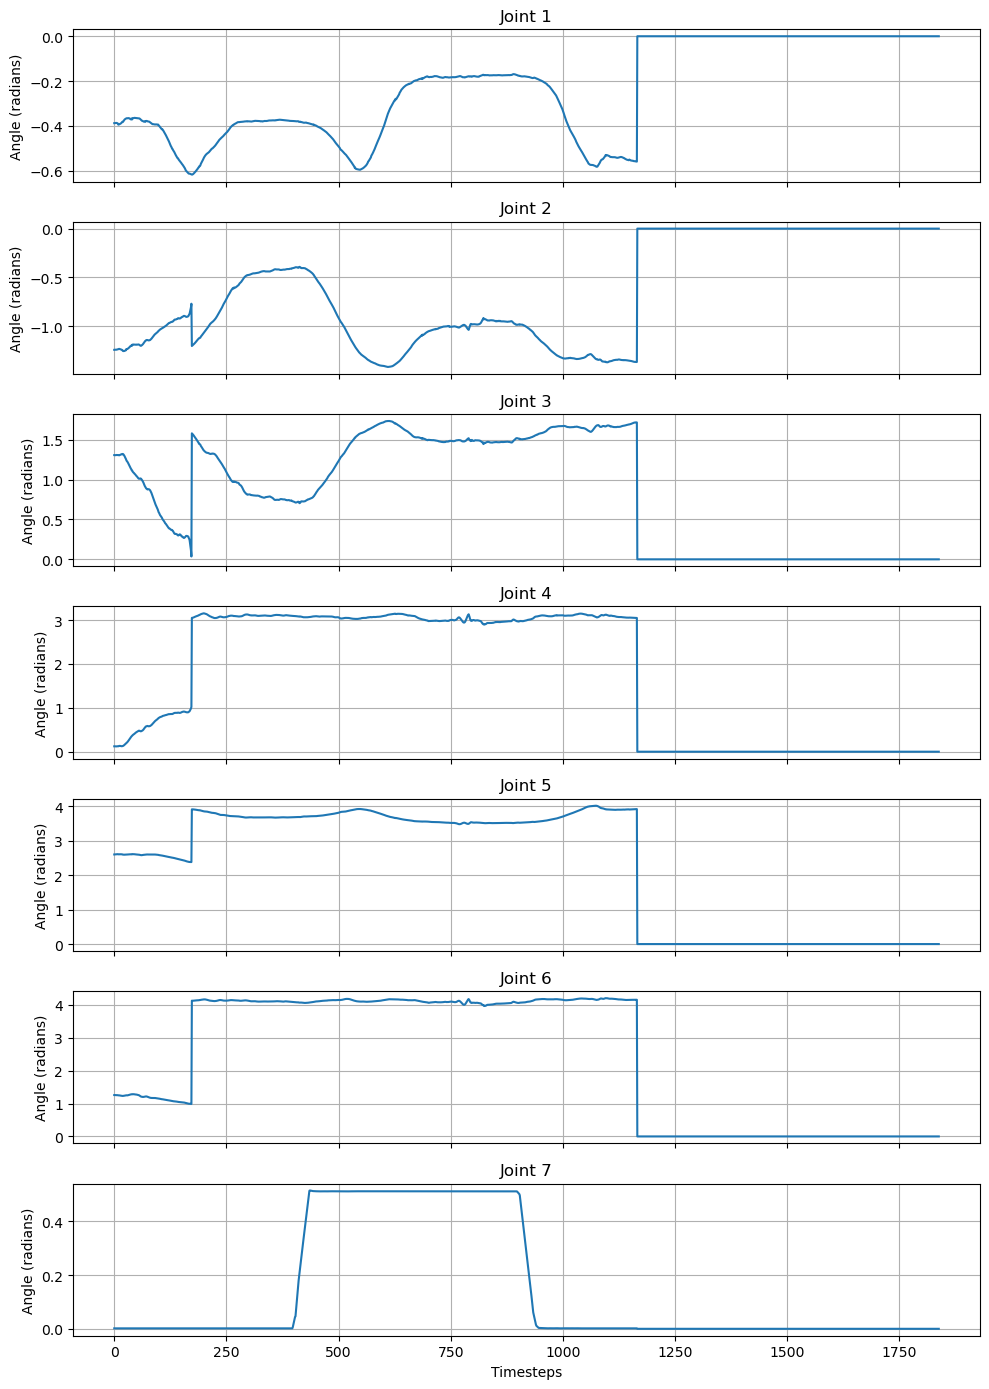

In [10]:
num_ur3_joints = 7
timesteps = np.arange(episode_len)
joint_trajectory = joint_action

# fig, axs = plt.subplots(num_ur3_joints, 1, figsize=(10, 2 * num_ur3_joints), sharex=True)

# for joint in range(num_ur3_joints):
#     axs[joint].plot(timesteps, joint_trajectory[:, joint], linestyle='-')
#     axs[joint].set_title(f'Joint {joint + 1}')
#     axs[joint].set_ylabel('Angle (radians)')
#     axs[joint].grid(True)

# axs[-1].set_xlabel('Timesteps')
# plt.tight_layout()
# plt.show()

plot_joint_trajectory(joint_trajectory, timesteps, num_ur3_joints)

for t, q in enumerate(joint_trajectory):
    pose_trajectory[t, :3, :4] = ur3_arm.forward(q[:-1], rotation_type='matrix')

In [7]:
from scipy.signal import savgol_filter

def smooth_trajectory(trajectory, window_length=7, polyorder=3):
    """
    Smooth the trajectory using a Savitzky–Golay filter.
    
    Parameters:
      trajectory : numpy.ndarray of shape (N, 6) where N is the number of time steps.
      window_length : int, the length of the filter window (must be odd and <= N).
      polyorder : int, the order of the polynomial used to fit the samples.
    
    Returns:
      smoothed trajectory as a numpy.ndarray of shape (N, 6)
    """
    # Ensure the window length is odd
    if window_length % 2 == 0:
        window_length += 1
    # If there are too few points, adjust the window_length accordingly.
    if trajectory.shape[0] < window_length:
        window_length = trajectory.shape[0] if trajectory.shape[0] % 2 == 1 else trajectory.shape[0] - 1
    return savgol_filter(trajectory, window_length, polyorder, axis=0)

In [8]:
smooth_joint_trajectory = smooth_trajectory(joint_trajectory)

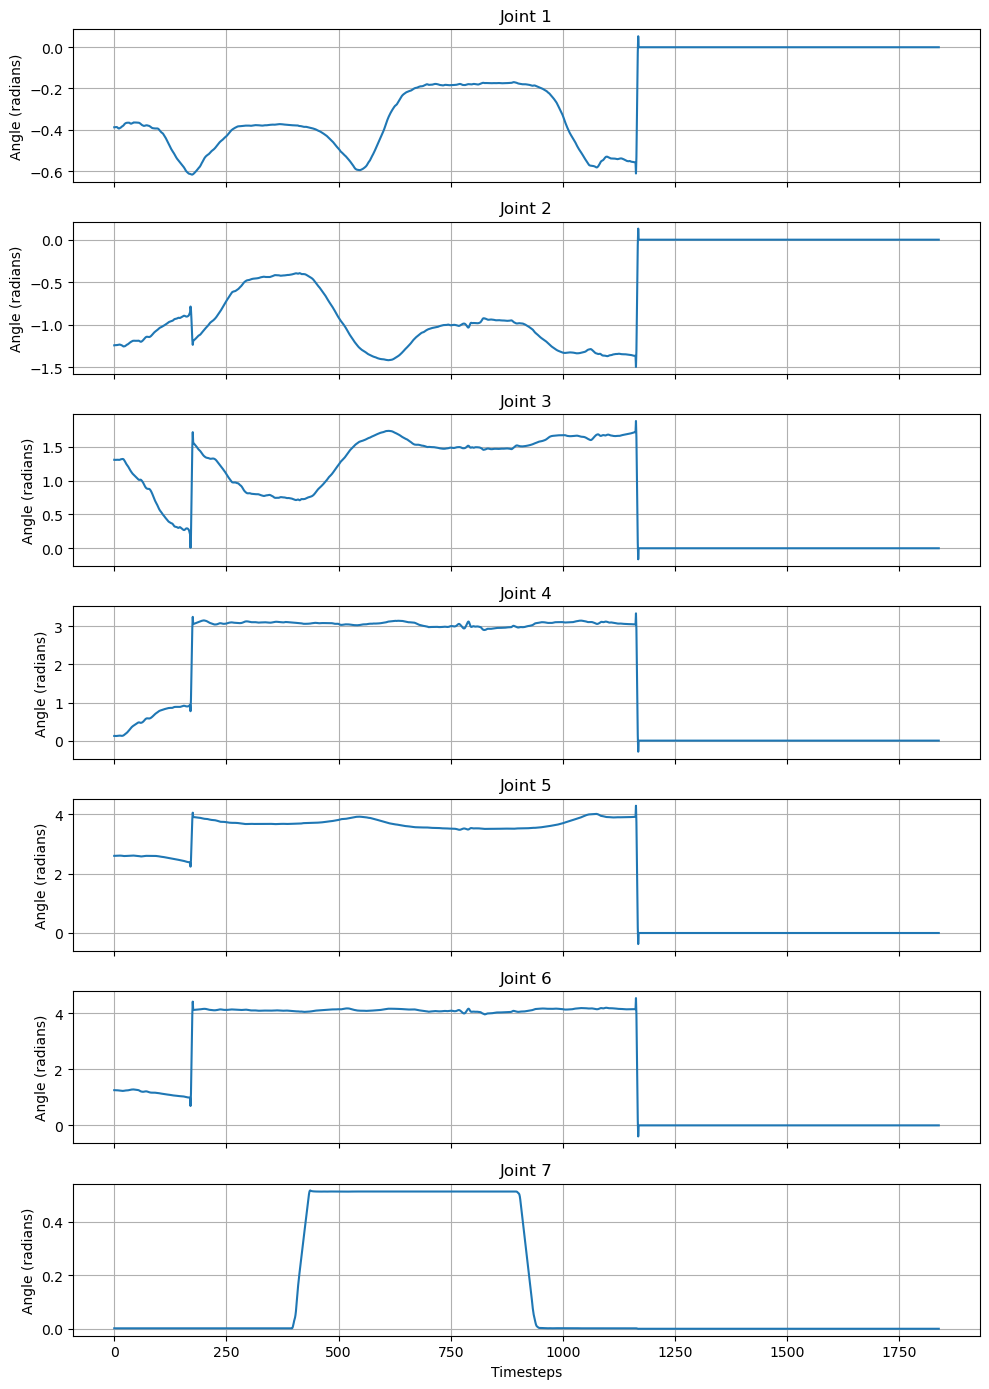

In [11]:
plot_joint_trajectory(smooth_joint_trajectory, timesteps, num_ur3_joints)

In [ ]:
plot_traj(pose_trajectory)

In [ ]:
plot_traj(tx_base_tcp)

In [ ]:
def similarity_check(original_pose, converted_pose):
    diff = np.linalg.inv(original_pose) @ converted_pose

    p_diff = diff[:3, 3]
    pos_err = np.linalg.norm(p_diff)

    R_diff = diff[:3, :3]
    trace_val = np.trace(R_diff)
    cos_angle = (trace_val - 1.0) / 2.0
    cos_angle = max(min(cos_angle, 1.0), -1.0)
    rot_err = np.arccos(cos_angle)

    return pos_err, rot_err

In [ ]:
errors = np.zeros((episode_len, 2))
for t in range(episode_len):
    try:
        pos_error, rot_error = (similarity_check(tx_base_tcp[t], pose_trajectory[t]))
        errors[t, 0] = pos_error
        errors[t, 1] = rot_error
    except Exception as e:
        print(e)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 2))

for ax in range(2):
    axs[ax].plot(timesteps, errors[:, ax], linestyle='-')
    axs[ax].grid(True)

axs[-1].set_xlabel('Timesteps')
plt.tight_layout()
plt.show()

In [ ]:
ur3_arm = ur_kinematics.URKinematics('ur3')

tx_tag_base = np.array([
    [
      0.014500569635805594,
      -0.9997530090623589,
      -0.016842041176650398,
      -0.044059934138102635
    ],
    [
      0.9996692201244223,
      0.014853059193052465,
      -0.02099611793729384,
      -0.4799630648844079
    ],
    [
      0.02124108792096622,
      -0.016532014498134257,
      0.9996376887055468,
      -0.02314005620630681
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  
  ])

tx_base_tag = np.linalg.inv(tx_tag_base)

num_episodes = 240
hdf5_path = '/home/soochul/GoPro_20250313_hdf5/'

error_list = list()

for episode_id in range(num_episodes):
    print("Episode id: ", episode_id)
    dataset_path = os.path.join(hdf5_path, f'ep_{episode_id}.hdf5')
    joint_dataset_path = os.path.join(hdf5_path, f'j_ep_{episode_id}.hdf5')

    
    with h5py.File(dataset_path, 'r') as root:
        is_sim = root.attrs['sim']
        original_action_shape = root['/action'].shape # ep length, 7
        episode_len = original_action_shape[0]
        start_ts = 0
        pose_action = root['/action'][start_ts:]

    with h5py.File(joint_dataset_path, 'r') as root:
        is_sim = root.attrs['sim']
        original_action_shape = root['/action'].shape # ep length, 7
        episode_len = original_action_shape[0]
        start_ts = 0
        joint_action = root['/action'][start_ts:]



    pose_trajectory = np.zeros((episode_len, 4, 4))


    eef_trajectory = np.zeros((episode_len, 4, 4))
    cam_pose = pose10d_to_mat(pose_action[:, :-1])
    tx_base_tcp = tx_base_tag @ cam_pose

    for t, q in enumerate(joint_trajectory):
      pose_trajectory[t, :3, :4] = ur3_arm.forward(q[:-1], rotation_type='matrix')
    
    num_ur3_joints = 7
    timesteps = np.arange(episode_len)
    joint_trajectory = action

    errors = np.zeros((episode_len, 2))
    for t in range(episode_len):
        try:
            pos_error, rot_error = (similarity_check(tx_base_tcp[t], pose_trajectory[t]))
            errors[t, 0] = pos_error
            errors[t, 1] = rot_error
            
        except Exception as e:
            print(e)
    error_list.append(errors)


In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 2))

errors = error_list[3]

for ax in range(2):
    axs[ax].plot(timesteps, errors[:, ax], linestyle='-')
    axs[ax].grid(True)

axs[-1].set_xlabel('Timesteps')
plt.tight_layout()
plt.show()